In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from dotenv import load_dotenv

load_dotenv()
DATA_PATH = os.getenv("DATA_PATH")
MODELS_PATH = os.path.join(os.path.dirname(DATA_PATH), "models")
RESULTS_PATH = os.path.join(os.path.dirname(DATA_PATH), "results")
PLOTS_PATH = os.getenv("PLOTS_PATH")

In [3]:
# carregando dataset de model2
df = pd.read_parquet(os.path.join(DATA_PATH, "model2_dataset.parquet"))
df.head()

,player_id,transfer_date,transfer_fee,predicted_value_m1,buyer_ratio,seller_ratio,buyer_league_tier,seller_league_tier,same_confederation,transfer_window,...,national_team_ranking_inv,goals_per_90,assists_per_90,buyer_net_transfer_record,buyer_national_team_players,buyer_stadium_seats,seller_net_transfer_record,seller_national_team_players,seller_stadium_seats,log_transfer_fee
0,81796,2010-01-01,2400000.0,1299041.375,1.000000,1.000000,4.0,5.0,0,1,...,0.0,0.0,0.0,14570000.0,15.0,60411.0,1260000.0,3.0,66704.0,14.690980
1,66515,2010-01-01,6000000.0,1648851.125,1.000000,1.000000,4.0,4.0,0,1,...,0.0,0.0,0.0,10000000.0,11.0,34725.0,23850000.0,5.0,24584.0,15.607270
2,42457,2010-01-01,600000.0,3445158.250,1.000000,1.000000,4.0,4.0,0,1,...,0.0,0.0,0.0,605000.0,1.0,28678.0,280000.0,11.0,55634.0,13.304687
3,33829,2010-01-09,1400000.0,3417337.500,1.847516,1.847516,1.0,1.0,1,1,...,0.0,0.0,0.0,86560000.0,6.0,32384.0,-47850000.0,20.0,25486.0,14.151984
4,38746,2010-01-11,800000.0,768312.625,1.187063,1.187063,4.0,1.0,1,1,...,0.0,0.0,0.0,4790000.0,2.0,6108.0,-182900000.0,19.0,62850.0,13.592368


In [4]:
# replicando split temporal de treino usado no treinamento (corte >= 2022)
df = df.sort_values("transfer_date").reset_index(drop=True)
df_test = df[df["transfer_date"] >= "2022-01-01"].copy()

# recuperando nomes de clubes e jogadores para visualização
datasets_path = os.getenv("DATASETS_PATH")
transfers = pd.read_csv(os.path.join(datasets_path, "transfers.csv"))
transfers["transfer_date"] = pd.to_datetime(transfers["transfer_date"])
df_test["transfer_date"] = pd.to_datetime(df_test["transfer_date"])
df_test = df_test.merge(
    transfers[["player_id", "transfer_date", "from_club_name", "to_club_name", "player_name"]],
    on=["player_id", "transfer_date"],
    how="left"
)
df_test = df_test.rename(columns={"from_club_name": "club_seller_name", "to_club_name": "club_buyer_name"})

print(f"amostras de teste: {len(df_test):,}")

amostras de teste: 4,894


In [5]:
# carregando lista de features usadas no treino
with open(os.path.join(MODELS_PATH, "feature_names_model2.pkl"), "rb") as f:
    feature_names = pickle.load(f)

X_test = df_test[feature_names]

In [6]:
# carregando os 3 modelos xgboost de regressão quantílica
model_p15 = xgb.XGBRegressor()
model_p15.load_model(os.path.join(MODELS_PATH, "model2_transfer_fee_p15.json"))

model_p50 = xgb.XGBRegressor()
model_p50.load_model(os.path.join(MODELS_PATH, "model2_transfer_fee_p50.json"))

model_p85 = xgb.XGBRegressor()
model_p85.load_model(os.path.join(MODELS_PATH, "model2_transfer_fee_p85.json"))

In [7]:
# gerando predições nos 3 quantis (escala log)
pred_p15_log = model_p15.predict(X_test)
pred_p50_log = model_p50.predict(X_test)
pred_p85_log = model_p85.predict(X_test)

# revertendo escala logarítmica para euros (expm1 é o inverso de log1p)
df_test["pred_p15"] = np.expm1(pred_p15_log)
df_test["pred_p50"] = np.expm1(pred_p50_log)
df_test["pred_p85"] = np.expm1(pred_p85_log)

# revertendo escala do target real
df_test["fee_real"] = np.expm1(df_test["log_transfer_fee"])

# garantindo que P15 <= P50 <= P85 (crossing quantiles)
df_test["pred_p15"] = np.minimum(df_test["pred_p15"], df_test["pred_p50"])
df_test["pred_p85"] = np.maximum(df_test["pred_p85"], df_test["pred_p50"])

In [8]:
# salvando csv de predições
df_preds = df_test[
    ["player_id", "transfer_date", "fee_real", "pred_p15", "pred_p50", "pred_p85"]
]
df_preds.to_csv(os.path.join(RESULTS_PATH, "predictions_test_model2.csv"), index=False)

In [9]:
# calculando métricas no conjunto de teste (P50 como predição principal)
y_real = df_test["fee_real"]
y_pred_p50 = df_test["pred_p50"]

mae = mean_absolute_error(y_real, y_pred_p50)
mape = np.mean(np.abs((y_real - y_pred_p50) / np.maximum(y_real, 1))) * 100
rmse = np.sqrt(mean_squared_error(y_real, y_pred_p50))
r2_real = r2_score(y_real, y_pred_p50)
r2_log = r2_score(np.log1p(y_real), np.log1p(y_pred_p50))

# calculando cobertura do intervalo P15–P85
in_interval = (y_real >= df_test["pred_p15"]) & (y_real <= df_test["pred_p85"])
coverage = in_interval.mean() * 100

metrics = {
    "MAE_P50": mae,
    "MAPE_P50": mape,
    "RMSE_P50": rmse,
    "R2_real": float(r2_real),
    "R2_log": float(r2_log),
    "Coverage_P15_P85": coverage,
}

with open(os.path.join(RESULTS_PATH, "metrics_model2.json"), "w") as f:
    json.dump(metrics, f, indent=4)

print(f"MAE:€ {mae:,.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: € {rmse:,.2f}")
print(f"R² (Log): {r2_log:.4f}")
print(f"R²: {r2_real:.4f}")
print(f"Cobertura P15–P85: {coverage:.2f}% (meta: ≥70%)")

MAE:€ 3,750,561.10
MAPE: 56.86%
RMSE: € 7,779,909.70
R² (Log): 0.6724
R²: 0.5990
Cobertura P15–P85: 53.92% (meta: ≥70%)


In [10]:
# calculando shap values com tree explainer (modelo P50)
explainer = shap.TreeExplainer(model_p50)
shap_values = explainer.shap_values(X_test)

with open(os.path.join(RESULTS_PATH, "shap_values_model2.pkl"), "wb") as f:
    pickle.dump(shap_values, f)

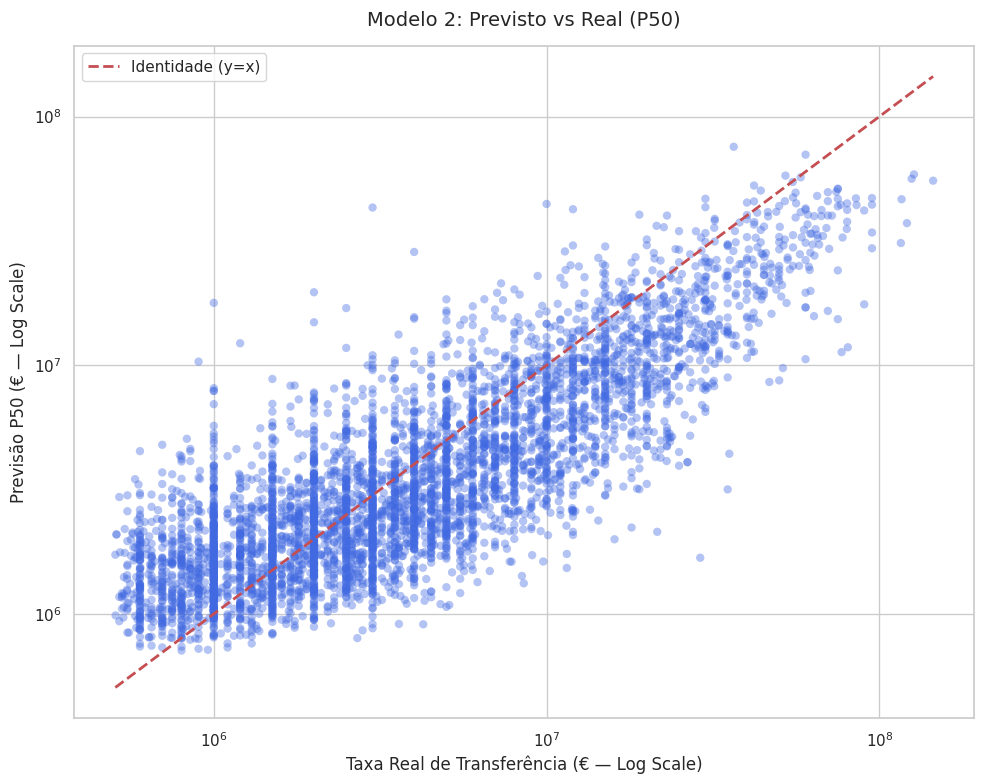

In [11]:
# scatter plot: P50 previsto vs fee real (escala log)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_real, y_pred_p50, alpha=0.4, color="royalblue", edgecolors="none")
lims = [min(y_real.min(), y_pred_p50.min()), max(y_real.max(), y_pred_p50.max())]
ax.plot(lims, lims, "r--", lw=2, label="Identidade (y=x)")
ax.set_xscale("log")
ax.set_yscale("log")

# Customização de títulos e eixos
ax.set_xlabel("Taxa Real de Transferência (€ — Log Scale)", fontsize=12)
ax.set_ylabel("Previsão P50 (€ — Log Scale)", fontsize=12)
ax.set_title("Modelo 2: Previsto vs Real (P50)", fontsize=14, pad=15)
ax.legend()

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model2_predicted_vs_real.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

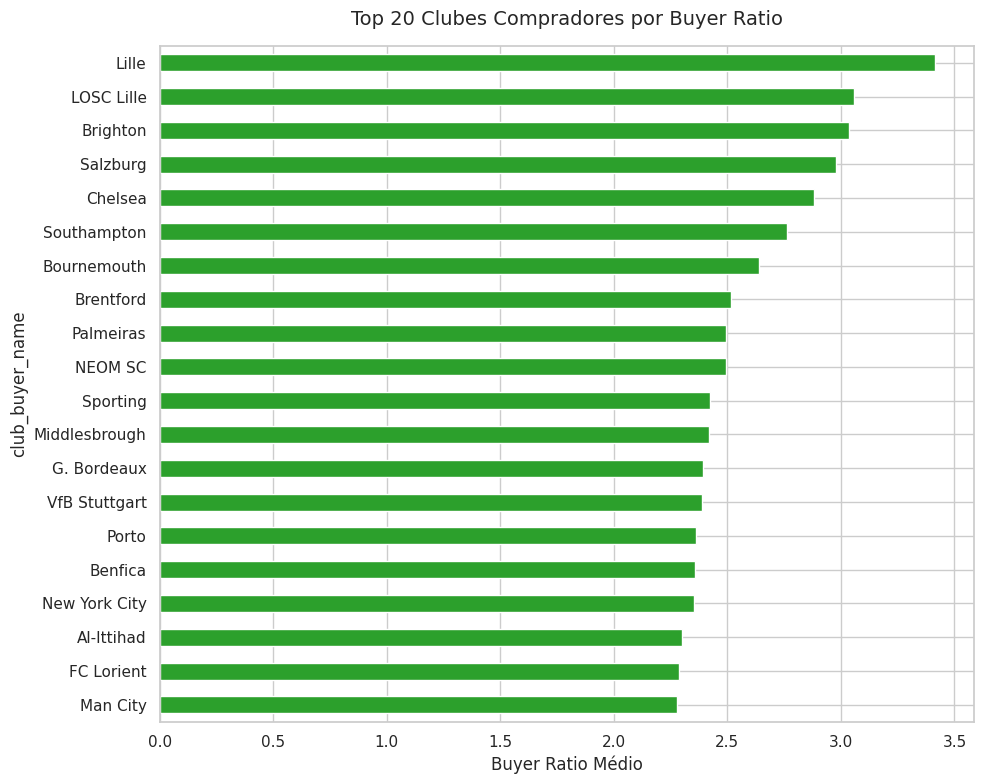

In [12]:
# barplot horizontal: top 20 clubes compradores por buyer_ratio médio
col_buyer = "club_buyer_name"

if "buyer_ratio" in df_test.columns and col_buyer in df_test.columns:
    top_buyers = (
        df_test.groupby(col_buyer)["buyer_ratio"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
        .sort_values()
    )
    fig, ax = plt.subplots(figsize=(10, 8))
    top_buyers.plot(kind="barh", color="#2ca02c", ax=ax)

    # Customização de títulos e eixos
    ax.set_xlabel("Buyer Ratio Médio", fontsize=12)
    ax.set_title("Top 20 Clubes Compradores por Buyer Ratio", fontsize=14, pad=15)

    # Exibe o gráfico e salva
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_PATH, "model2_club_buyer_ratio.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

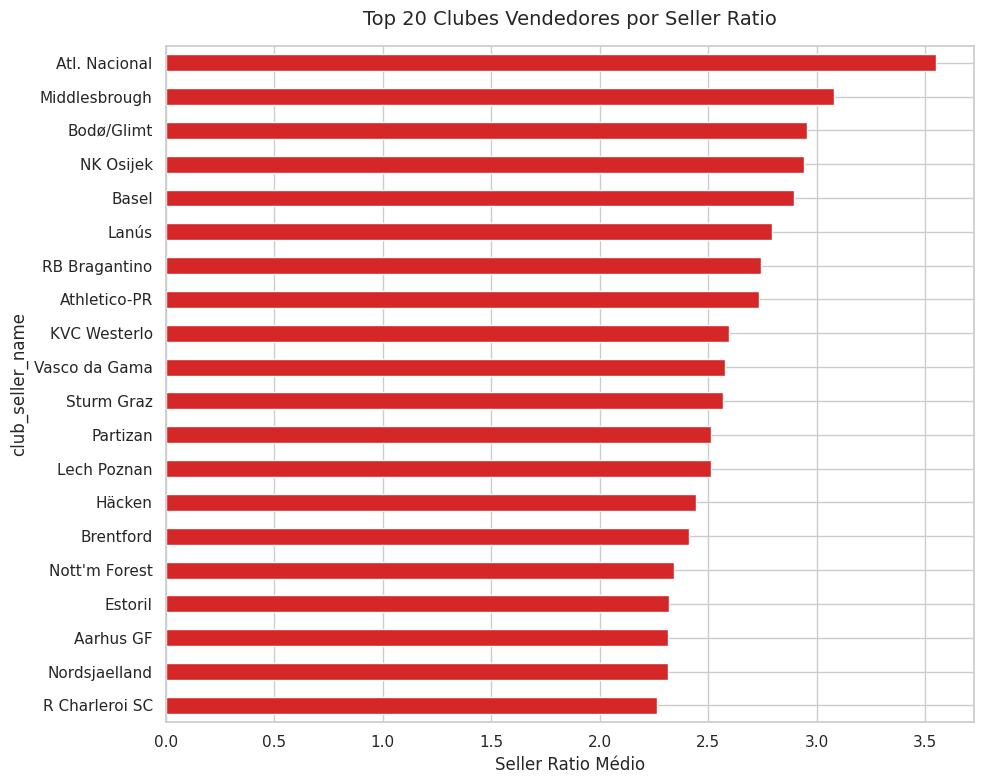

In [13]:
# barplot horizontal: top 20 clubes vendedores por seller_ratio médio
col_seller = "club_seller_name"

if "seller_ratio" in df_test.columns and col_seller in df_test.columns:
    top_sellers = (
        df_test.groupby(col_seller)["seller_ratio"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
        .sort_values()
    )
    fig, ax = plt.subplots(figsize=(10, 8))
    top_sellers.plot(kind="barh", color="#d62728", ax=ax)

    # Customização de títulos e eixos
    ax.set_xlabel("Seller Ratio Médio", fontsize=12)
    ax.set_title("Top 20 Clubes Vendedores por Seller Ratio", fontsize=14, pad=15)

    # Exibe o gráfico e salva
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_PATH, "model2_club_seller_ratio.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

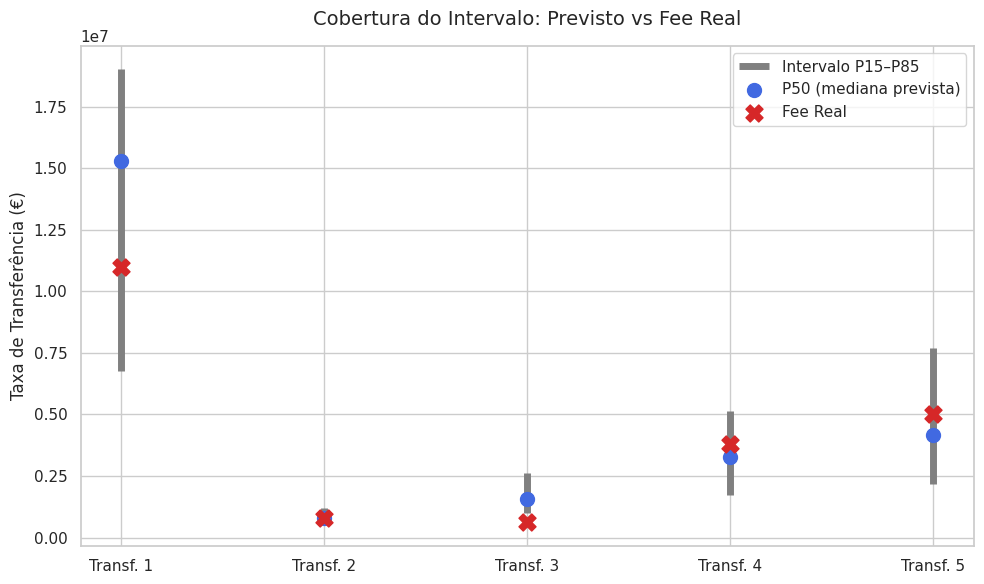

In [14]:
# plotando 5 exemplos aleatórios de cobertura do intervalo P15–P85
np.random.seed(42)
sample_idx = np.random.choice(df_test.index, size=5, replace=False)
df_sample = df_test.loc[sample_idx].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
for i, row in df_sample.iterrows():
    ax.vlines(
        x=i,
        ymin=row["pred_p15"],
        ymax=row["pred_p85"],
        color="gray",
        linewidth=5,
        label="Intervalo P15–P85" if i == 0 else "",
    )
    ax.scatter(
        i,
        row["pred_p50"],
        color="royalblue",
        s=100,
        zorder=3,
        label="P50 (mediana prevista)" if i == 0 else "",
    )
    ax.scatter(
        i,
        row["fee_real"],
        color="#d62728",
        marker="X",
        s=150,
        zorder=4,
        label="Fee Real" if i == 0 else "",
    )

# Customização de títulos e eixos
ax.set_xticks(range(5))
ax.set_xticklabels([f"Transf. {j+1}" for j in range(5)])
ax.set_ylabel("Taxa de Transferência (€)", fontsize=12)
ax.set_title("Cobertura do Intervalo: Previsto vs Fee Real", fontsize=14, pad=15)
ax.legend()

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model2_confidence_interval_examples.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

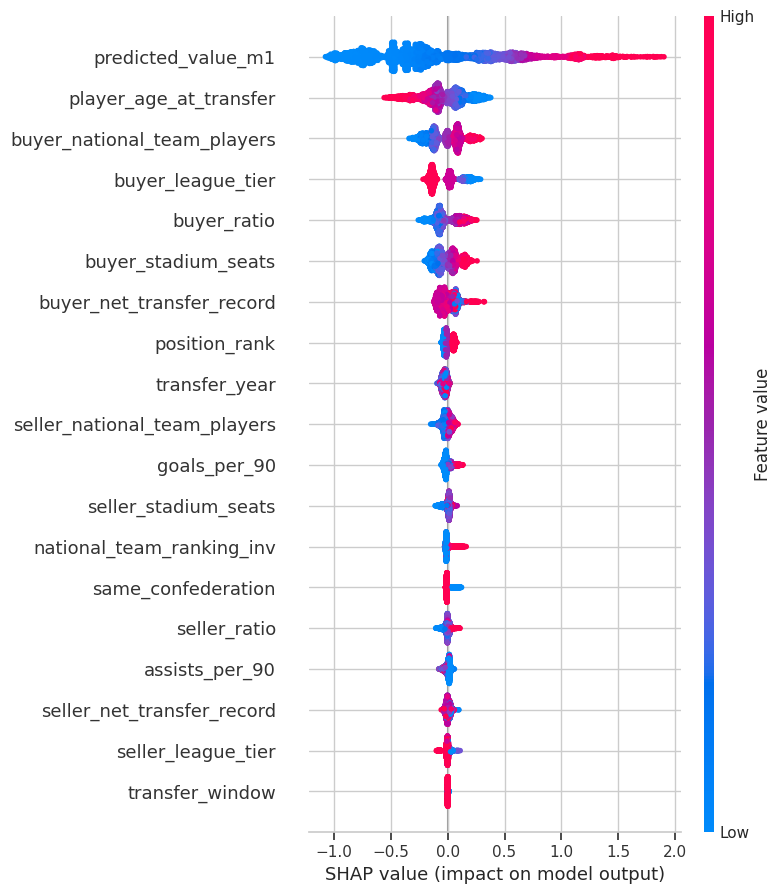

In [15]:
# shap summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model2_shap_summary.png"), dpi=300, bbox_inches="tight"
)
plt.show()

In [16]:
# criando coluna de erro percentual absoluto
df_test["ape"] = np.abs(
    (df_test["fee_real"] - df_test["pred_p50"]) / np.maximum(df_test["fee_real"], 1)
)

In [17]:
# isolando casos muito acima do teto (fee_real > 2x P85) e muito abaixo do piso (fee_real < 0.5x P15)
outliers_high = df_test[df_test["fee_real"] > (2 * df_test["pred_p85"])]
outliers_low = df_test[df_test["fee_real"] < (0.5 * df_test["pred_p15"])]

print(f"cobertura total P15–P85: {coverage:.2f}%")
print(f"casos muito acima do teto (fee_real > 2x P85): {len(outliers_high)}")
print(f"casos muito abaixo do piso (fee_real < 0.5x P15): {len(outliers_low)}")

cobertura total P15–P85: 53.92%
casos muito acima do teto (fee_real > 2x P85): 218
casos muito abaixo do piso (fee_real < 0.5x P15): 104


In [18]:
# top 5 transferências subestimadas (mercado pagou muito acima do teto)
cols_ctx = [
    "player_name",
    "club_buyer_name",
    "club_seller_name",
    "fee_real",
    "pred_p15",
    "pred_p50",
    "pred_p85",
]
display(outliers_high[cols_ctx].sort_values("fee_real", ascending=False).head(5))

,player_name,club_buyer_name,club_seller_name,fee_real,pred_p15,pred_p50,pred_p85
1077,Enzo Fernández,Chelsea,Benfica,121000000.0,30465260.0,37262584.0,44512236.0
1482,Declan Rice,Arsenal,West Ham,116600000.0,43140928.0,46491824.0,56305780.0
1732,Moisés Caicedo,Chelsea,Brighton,116000000.0,21866012.0,30999368.0,41456112.0
1745,Neymar,Al-Hilal,PSG,90000000.0,7710702.5,17569532.0,43066360.0
830,Wesley Fofana,Chelsea,Leicester,80400000.0,5959249.5,11806452.0,20393612.0


In [19]:
# top 5 transferências superestimadas (venda muito abaixo do piso previsto)
display(outliers_low[cols_ctx].sort_values("fee_real", ascending=True).head(5))

,player_name,club_buyer_name,club_seller_name,fee_real,pred_p15,pred_p50,pred_p85
249,Magnus Kofod Andersen,Venezia,Nordsjaelland,510000.0,1122744.750,2087098.25,3302570.50
1037,Ryan Porteous,Watford,Hibernian FC,510000.0,1096968.500,2086996.75,3594995.75
1816,Gonzalo Martínez,River Plate,Al-Nassr,520000.0,1744942.000,2951125.25,5697130.50
1351,Nikita Goylo,Zenit S-Pb,Pari NN,540000.0,1124063.500,2195119.50,3465539.50
995,Cyril Ngonge,Hellas Verona,FC Groningen,550000.0,1510367.625,2997661.75,5322696.00


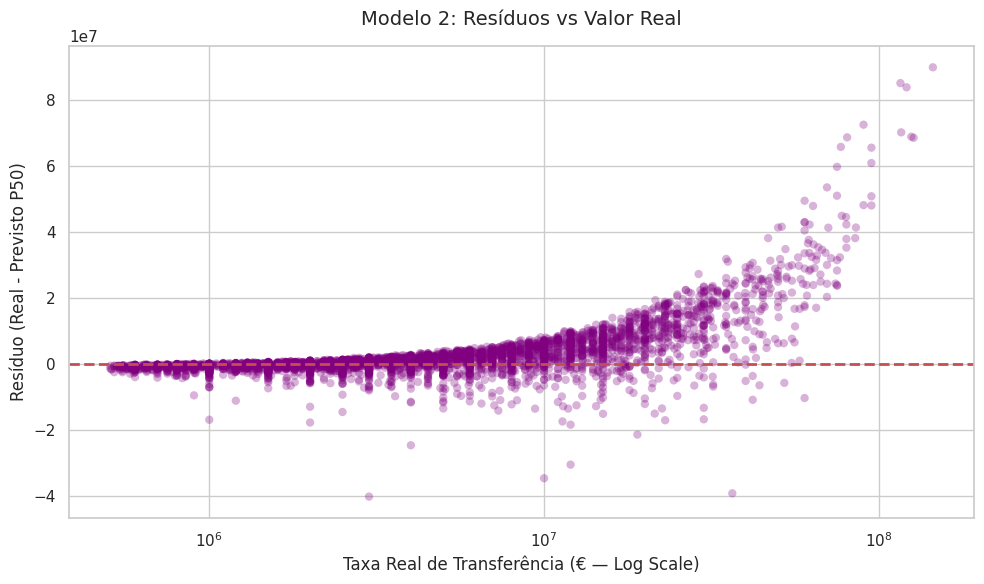

In [20]:
# 1. Scatter plot: Erros (Resíduos) vs Valor Real
df_test["residual"] = df_test["fee_real"] - df_test["pred_p50"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_test["fee_real"], df_test["residual"], alpha=0.3, color="purple", edgecolors="none")
ax.axhline(0, color="r", linestyle="--", lw=2)
ax.set_xscale("log")
ax.set_xlabel("Taxa Real de Transferência (€ — Log Scale)", fontsize=12)
ax.set_ylabel("Resíduo (Real - Previsto P50)", fontsize=12)
ax.set_title("Modelo 2: Resíduos vs Valor Real", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "model2_residuals_vs_real.png"), dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# 2. Boxplots de MAPE (APE) por faixa de valor
bins = [0, 1e6, 5e6, 20e6, float('inf')]
labels = ["<1M", "1M-5M", "5M-20M", ">20M"]
df_test["value_group"] = pd.cut(df_test["fee_real"], bins=bins, labels=labels, right=False)

/tmp/ipykernel_43671/1396178684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_test, x="value_group", y="ape", showfliers=False, palette="Set2", ax=ax)


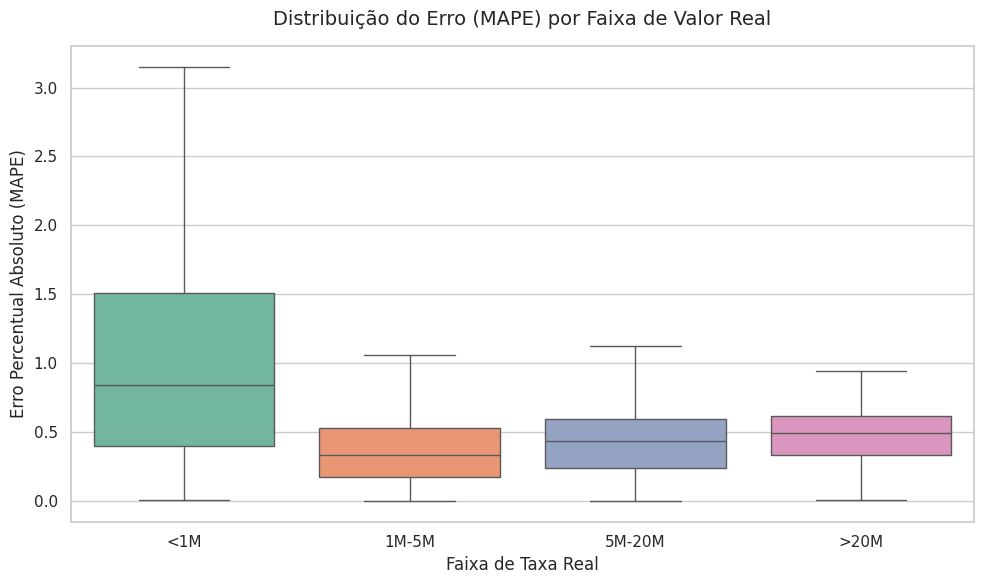

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_test, x="value_group", y="ape", showfliers=False, palette="Set2", ax=ax)
ax.set_xlabel("Faixa de Taxa Real", fontsize=12)
ax.set_ylabel("Erro Percentual Absoluto (MAPE)", fontsize=12)
ax.set_title("Distribuição do Erro (MAPE) por Faixa de Valor Real", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "model2_mape_by_value_group.png"), dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# 3. Matriz de Confusão de Predição (Crosstab)
df_test["pred_group"] = pd.cut(df_test["pred_p50"], bins=bins, labels=labels, right=False)
conf_matrix = pd.crosstab(df_test["value_group"], df_test["pred_group"], rownames=["Real"], colnames=["Previsto"])

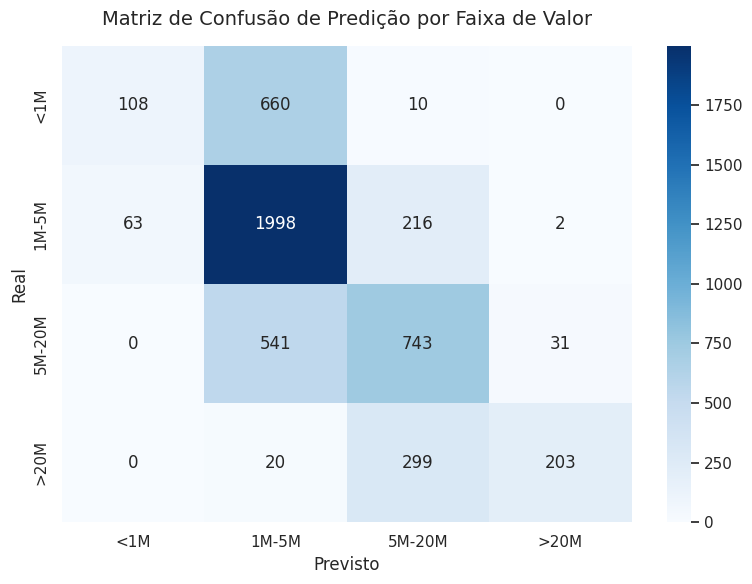

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusão de Predição por Faixa de Valor", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "model2_prediction_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# 4. SHAP Dependence Plot
shap_data = shap_values.values if hasattr(shap_values, "values") else shap_values

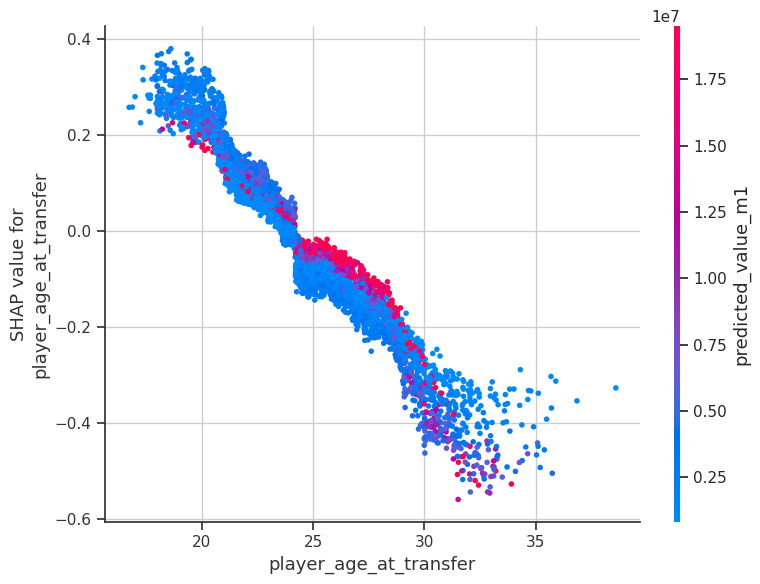

In [26]:
# Dependência: player_age_at_transfer
if "player_age_at_transfer" in X_test.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    shap.dependence_plot("player_age_at_transfer", shap_data, X_test, show=False, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, "model2_shap_dependence_age.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Coluna 'player_age_at_transfer' não encontrada em X_test.")

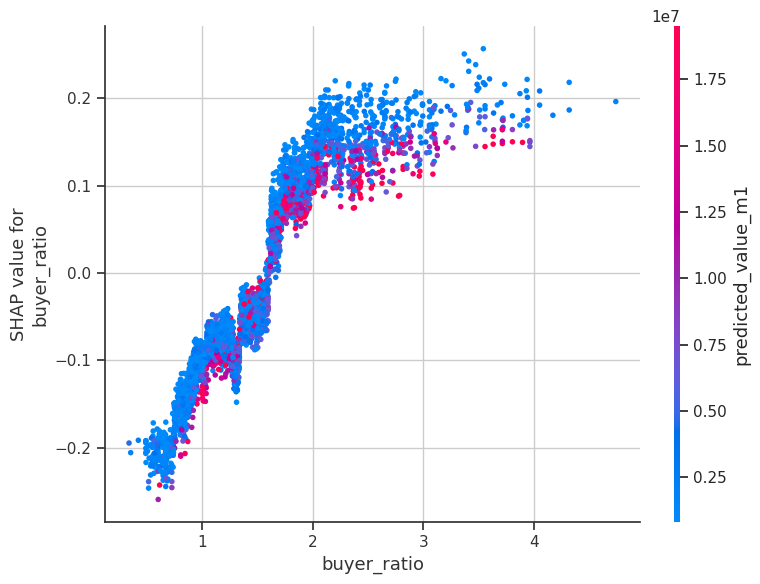

In [27]:
# Dependência: buyer_ratio
if "buyer_ratio" in X_test.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    shap.dependence_plot("buyer_ratio", shap_data, X_test, show=False, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_PATH, "model2_shap_dependence_buyer_ratio.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Coluna 'buyer_ratio' não encontrada em X_test.")